In [1]:
# ===== 1. 导入工具库 =====
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')   # 忽略不影响结果的警告

# ===== 2. 读取数据（关键：编码必须用 unicode_escape）=====
df = pd.read_csv('Diwali Sales Data.csv', encoding='unicode_escape')

# ===== 3. 查看数据基本情况 =====
print('数据形状(行,列):', df.shape)
df.head()


数据形状(行,列): (11251, 15)


,User_ID,Cust_name,Product_ID,Gender,Age Group,Age,Marital_Status,State,Zone,Occupation,Product_Category,Orders,Amount,Status,unnamed1
0,1002903,Sanskriti,P00125942,F,26-35,28,0,Maharashtra,Western,Healthcare,Auto,1,23952.0,NaN,NaN
1,1000732,Kartik,P00110942,F,26-35,35,1,Andhra Pradesh,Southern,Govt,Auto,3,23934.0,NaN,NaN
2,1001990,Bindu,P00118542,F,26-35,35,1,Uttar Pradesh,Central,Automobile,Auto,3,23924.0,NaN,NaN
3,1001425,Sudevi,P00237842,M,0-17,16,0,Karnataka,Southern,Construction,Auto,2,23912.0,NaN,NaN
4,1000588,Joni,P00057942,M,26-35,28,1,Gujarat,Western,Food Processing,Auto,2,23877.0,NaN,NaN


In [2]:
# —— 最小准备：让Python数据和SQL清洗后一致（直接跑）——
df.drop(columns=['Status','unnamed1'], inplace=True)              # 删2个空列
df.dropna(subset=['Amount'], inplace=True)                        # 删金额空行
key_cols = ['User_ID','Cust_name','Product_ID','Gender','Age',
            'Product_Category','Occupation','Orders','Amount','Marital_Status']
df.drop_duplicates(subset=key_cols, keep='first', inplace=True)   # 去重
df['Gender'] = df['Gender'].map({'F':'Female','M':'Male'})        # 性别转全称
df['Marital_Status'] = df['Marital_Status'].map({0:'Unmarried',1:'Married'}) # 婚姻
print('准备完成，形状(行,列):', df.shape)


准备完成，形状(行,列): (11175, 13)


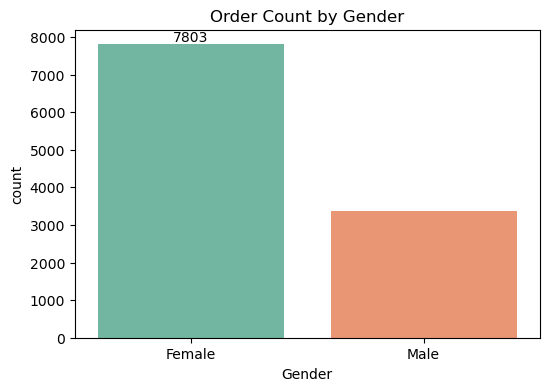

Gender
Female    74121867.43
Male      31625689.00
Name: Amount, dtype: float64


In [5]:
# 图1：男女购买笔数（countplot = 自动数每类多少条，相当于 SQL 的 COUNT(*) GROUP BY Gender）
plt.figure(figsize=(6,4))
ax = sns.countplot(x='Gender', data=df, palette='Set2')
ax.bar_label(ax.containers[0])      # 在柱子上标数字
plt.title('Order Count by Gender')
plt.show()
# 数字：男女销售额（相当于 SQL 的 GROUP BY Gender + SUM(Amount)）
gender_sales = df.groupby('Gender')['Amount'].sum().sort_values(ascending=False)
print(gender_sales)



Gender
Female    74121867.43
Male      31625689.00
Name: Amount, dtype: float64


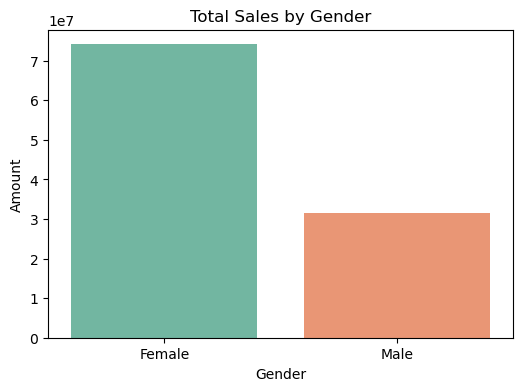

In [6]:
# 图2：男女销售额柱状图
plt.figure(figsize=(6,4))
sns.barplot(x=gender_sales.index, y=gender_sales.values, palette='Set2')
plt.title('Total Sales by Gender')
plt.ylabel('Amount')
plt.show()

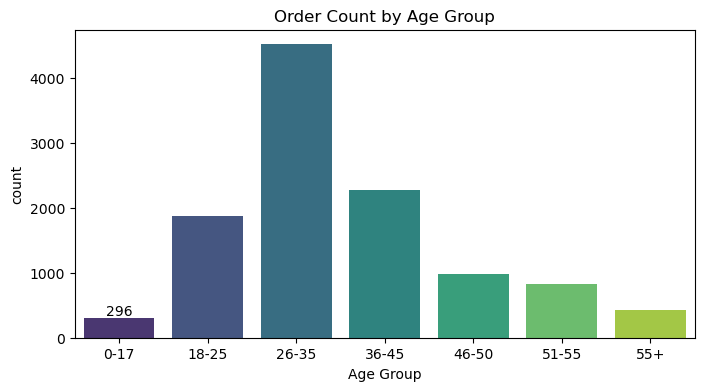

Age Group
0-17      2699653.00
18-25    17170254.00
26-35    42398334.94
36-45    22028795.49
46-50     9182706.00
51-55     8190959.00
55+       4076854.00
Name: Amount, dtype: float64


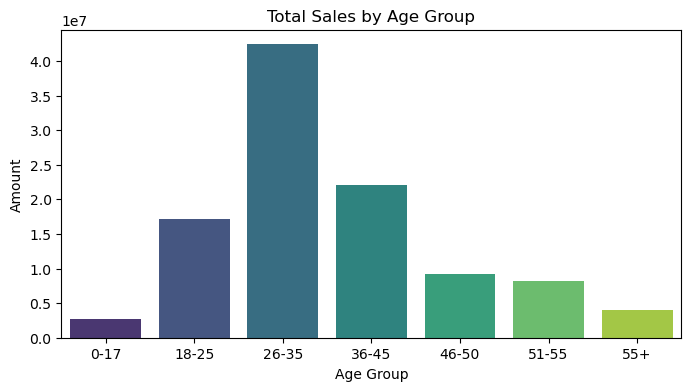

In [8]:
age_order = ['0-17','18-25','26-35','36-45','46-50','51-55','55+']  # 手动指定顺序

plt.figure(figsize=(8,4))
ax = sns.countplot(x='Age Group', data=df, order=age_order, palette='viridis')
ax.bar_label(ax.containers[0])
plt.title('Order Count by Age Group'); plt.show()

age_sales = df.groupby('Age Group')['Amount'].sum().reindex(age_order)
print(age_sales)
plt.figure(figsize=(8,4))
sns.barplot(x=age_sales.index, y=age_sales.values, palette='viridis')
plt.title('Total Sales by Age Group'); plt.ylabel('Amount'); plt.show()


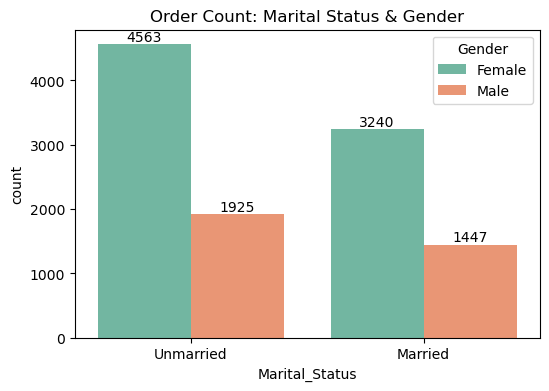

  Marital_Status  Gender       Amount
0        Married  Female  30415073.99
1        Married    Male  13427360.00
2      Unmarried  Female  43706793.44
3      Unmarried    Male  18198329.00


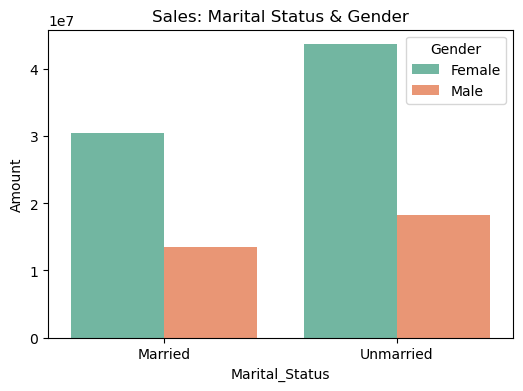

In [9]:
plt.figure(figsize=(6,4))
ax = sns.countplot(x='Marital_Status', hue='Gender', data=df, palette='Set2')
for c in ax.containers: ax.bar_label(c)
plt.title('Order Count: Marital Status & Gender'); plt.show()

ms = df.groupby(['Marital_Status','Gender'])['Amount'].sum().reset_index()
print(ms)
plt.figure(figsize=(6,4))
sns.barplot(x='Marital_Status', y='Amount', hue='Gender', data=ms, palette='Set2')
plt.title('Sales: Marital Status & Gender'); plt.show()
